# Profiling Visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

CSV_PATH = "profiling_results_20260417_211633.csv"

df = pd.read_csv(CSV_PATH)

# Shared palette: MCP = blue, Text2SQL = coral/orange
PALETTE = {"mcp": "#185FA5", "text2sql": "#D85A30"}

# Global aesthetics
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 120

print(f"Loaded {len(df)} rows — modes: {df['mode'].value_counts().to_dict()}")

Loaded 54 rows — modes: {'mcp': 27, 'text2sql': 27}


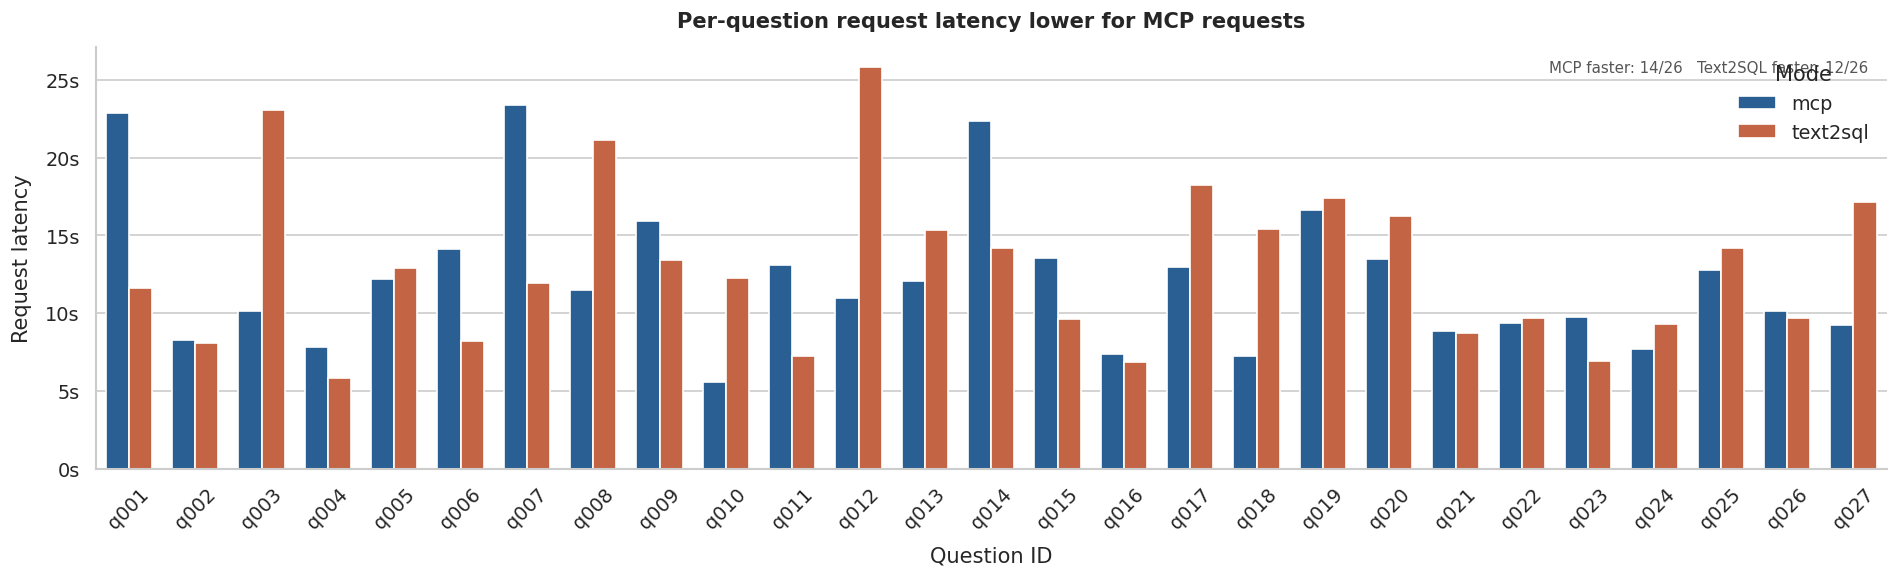

In [2]:
pivot = (
    df.pivot_table(index="question_id", columns="mode", values="client_request_latency_ms")
    .reset_index()
    .sort_values("question_id")
)

# Melt back to long form for seaborn
long = pivot.melt(id_vars="question_id", var_name="mode", value_name="latency_ms")

fig, ax = plt.subplots(figsize=(16, 5))

sns.barplot(
    data=long,
    x="question_id",
    y="latency_ms",
    hue="mode",
    palette=PALETTE,
    width=0.7,
    ax=ax,
)

# Y-axis in seconds
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}s"))
ax.set_xlabel("Question ID", labelpad=8)
ax.set_ylabel("Request latency", labelpad=8)
ax.set_title("Per-question request latency lower for MCP requests", fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=45)

# Annotate which mode won for each question
mcp_faster = (pivot["mcp"] < pivot["text2sql"]).sum()
ax.text(
    0.99, 0.97,
    f"MCP faster: {mcp_faster}/26   Text2SQL faster: {26-mcp_faster}/26",
    transform=ax.transAxes, ha="right", va="top",
    fontsize=9, color="#555",
)

ax.legend(title="Mode", frameon=False)
plt.tight_layout()
plt.show()

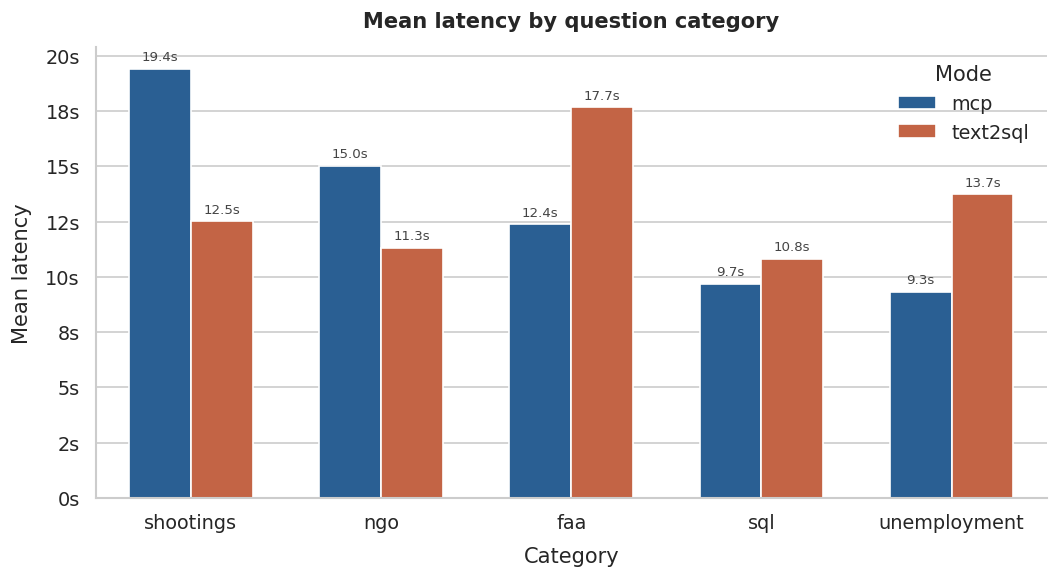

In [3]:
cat_means = (
    df.groupby(["mode", "category"])["client_request_latency_ms"]
    .mean()
    .reset_index()
)

# Category order by descending MCP latency for readability
order = (
    cat_means[cat_means["mode"] == "mcp"]
    .sort_values("client_request_latency_ms", ascending=False)["category"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=cat_means,
    x="category",
    y="client_request_latency_ms",
    hue="mode",
    palette=PALETTE,
    order=order,
    width=0.65,
    ax=ax,
)

# Add value labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda v: f"{v/1000:.1f}s",
        padding=3,
        fontsize=8,
        color="#444",
    )

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}s"))
ax.set_xlabel("Category", labelpad=8)
ax.set_ylabel("Mean latency", labelpad=8)
ax.set_title("Mean latency by question category", fontweight="bold", pad=12)
ax.legend(title="Mode", frameon=False)
plt.tight_layout()
plt.show()

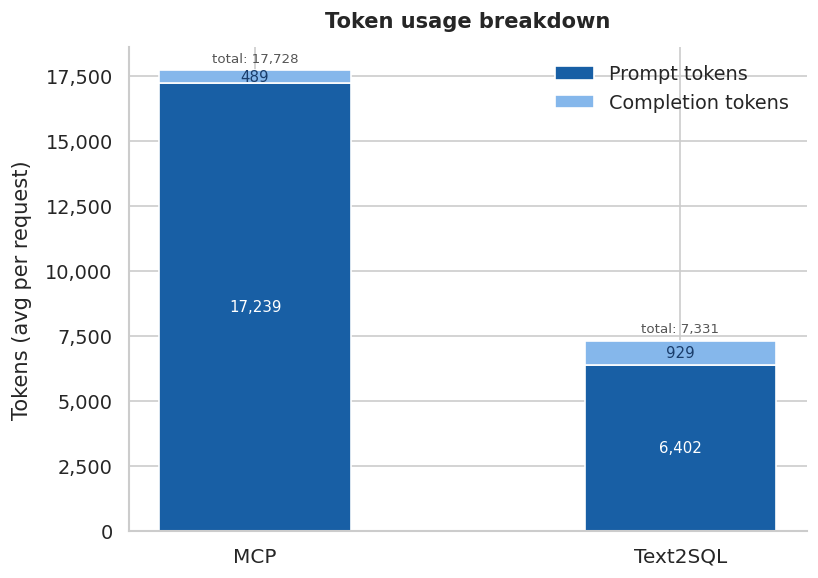

In [4]:
token_means = (
    df.groupby("mode")[["prompt_tokens", "completion_tokens"]]
    .mean()
    .reset_index()
)

# Consistent mode order
token_means["mode"] = pd.Categorical(token_means["mode"], categories=["mcp", "text2sql"])
token_means = token_means.sort_values("mode")

fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(token_means))
w = 0.45

prompt_bars = ax.bar(
    x, token_means["prompt_tokens"], width=w,
    color="#185FA5", label="Prompt tokens"
)
completion_bars = ax.bar(
    x, token_means["completion_tokens"],
    bottom=token_means["prompt_tokens"], width=w,
    color="#85B7EB", label="Completion tokens"
)

# Annotate segment values
for i, row in token_means.iterrows():
    idx = list(token_means.index).index(i)
    # prompt label (inside bar)
    ax.text(idx, row["prompt_tokens"] / 2,
            f"{row['prompt_tokens']:,.0f}",
            ha="center", va="center", fontsize=9, color="white")
    # completion label (inside bar)
    ax.text(idx, row["prompt_tokens"] + row["completion_tokens"] / 2,
            f"{row['completion_tokens']:,.0f}",
            ha="center", va="center", fontsize=9, color="#1a3d6b")
    # total above bar
    total = row["prompt_tokens"] + row["completion_tokens"]
    ax.text(idx, total + 200, f"total: {total:,.0f}",
            ha="center", va="bottom", fontsize=8, color="#555")

ax.set_xticks(x)
ax.set_xticklabels(["MCP", "Text2SQL"], fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_ylabel("Tokens (avg per request)", labelpad=8)
ax.set_title("Token usage breakdown", fontweight="bold", pad=12)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## LLM Correctness Evaluation Against MySQL Ground Truth

This section performs one separate GPT-5-mini evaluation call per profiling row.

- Ground truth is fetched directly from MySQL with deterministic SQL per `question_id`.
- MCP rows are scored using `response_text`.
- Text2SQL rows are scored using `query_results`.
- Correctness uses exact-value semantics with tolerant formatting/order.

In [2]:
from pathlib import Path
from urllib.parse import urlparse
import json
import re
import time

import mysql.connector
from openai import OpenAI


def find_file_upwards(start_path: Path, filename: str) -> Path:
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        target = candidate / filename
        if target.exists():
            return target
    raise FileNotFoundError(f"Could not find {filename} by walking parents from {start_path}")


def to_text(value):
    if value is None:
        return ""
    if isinstance(value, float) and np.isnan(value):
        return ""
    return str(value)


def select_canonical_response(row):
    if str(row.get("mode", "")).lower() == "text2sql":
        primary = row.get("query_results", "")
    else:
        primary = row.get("response_text", "")

    primary_text = to_text(primary).strip()
    if primary_text:
        return primary_text

    return to_text(row.get("final_llm_response", "")).strip()


def dataframe_to_csv_text(dataframe: pd.DataFrame, max_rows: int = 200) -> str:
    if dataframe is None or dataframe.empty:
        return "No rows found."

    preview = dataframe.head(max_rows).copy()
    for col in preview.columns:
        preview[col] = preview[col].apply(to_text)
    return preview.to_csv(index=False)


SQL_MAP = {
    "q001": (
        """
        SELECT IncidentID, Address, IncidentDate, State, CityOrCountry,
               VictimsKilled, VictimsInjured, SuspectsInjured, SuspectsKilled, SuspectsArrested
        FROM us_shootings
        WHERE LOWER(State) = %s AND YEAR(IncidentDate) = %s
        ORDER BY IncidentDate
        LIMIT 5
        """,
        ("louisiana", 2014),
    ),
    "q002": (
        """
        SELECT State, Rate_2022, Rate_2023, Rate_Change, State_Rank
        FROM unemployment_rates_by_state
        WHERE State = %s
        """,
        ("Georgia",),
    ),
    "q003": (
        """
        SELECT State, Rate_2022, Rate_2023, Rate_Change, State_Rank
        FROM unemployment_rates_by_state
        WHERE State IN (%s, %s)
        ORDER BY FIELD(State, %s, %s)
        """,
        ("Hawaii", "Indiana", "Hawaii", "Indiana"),
    ),
    "q004": (
        """
        SELECT State, Rate_2022
        FROM unemployment_rates_by_state
        ORDER BY Rate_2022 ASC, State ASC
        LIMIT 5
        """,
        (),
    ),
    "q005": (
        """
        SELECT Ein, Name, Fulladdr, City, State, Zip, County, Ntee_Code, Category, Is_Category_Llm_Generated
        FROM ngos_with_categorization
        WHERE Ein = %s
        """,
        (100006500,),
    ),
    "q006": (
        """
        SELECT Ein, Name, City, State, County, Ntee_Code, Category
        FROM ngos_with_categorization
        WHERE County = %s
        ORDER BY Ein
        LIMIT 10
        """,
        ("Albany County",),
    ),
    "q007": (
        """
        SELECT State, COUNT(*) AS religion_ngos
        FROM ngos_with_categorization
        WHERE Category LIKE %s
        GROUP BY State
        ORDER BY religion_ngos DESC, State ASC
        LIMIT 10
        """,
        ("%Religion%",),
    ),
    "q008": (
        """
        SELECT *
        FROM faa_master
        WHERE n_number = %s
        LIMIT 1
        """,
        ("N100",),
    ),
    "q009": (
        """
        SELECT IncidentID, Address, IncidentDate, State, CityOrCountry,
               VictimsKilled, VictimsInjured, SuspectsInjured, SuspectsKilled, SuspectsArrested
        FROM us_shootings
        WHERE LOWER(State) = %s
        ORDER BY IncidentDate DESC
        LIMIT 5
        """,
        ("texas",),
    ),
    "q010": (
        """
        SELECT State, Rate_2023
        FROM unemployment_rates_by_state
        ORDER BY Rate_2023 DESC, State ASC
        LIMIT 1
        """,
        (),
    ),
    "q011": (
        """
        SELECT State, Rate_2022, Rate_2023, Rate_Change, State_Rank
        FROM unemployment_rates_by_state
        ORDER BY Rate_2023 DESC, State ASC
        LIMIT 10
        """,
        (),
    ),
    "q012": (
        """
        SELECT State, Rate_2022, Rate_2023, Rate_Change, State_Rank
        FROM unemployment_rates_by_state
        WHERE State IN (%s, %s)
        ORDER BY FIELD(State, %s, %s)
        """,
        ("California", "United States", "California", "United States"),
    ),
    "q013": (
        """
        SELECT Ein, Name, City, State, County, Ntee_Code, Category
        FROM ngos_with_categorization
        WHERE State = %s AND Category = %s
        ORDER BY Ein
        LIMIT 5
        """,
        ("CA", "Health Care"),
    ),
    "q014": (
        """
        SELECT Ein, Name, City, State, County, Ntee_Code, Category
        FROM ngos_with_categorization
        WHERE County = %s
        ORDER BY Ein
        LIMIT 10
        """,
        ("King County",),
    ),
    "q015": (
        """
        SELECT Category, COUNT(*) AS ngo_count
        FROM ngos_with_categorization
        WHERE State = %s
        GROUP BY Category
        ORDER BY ngo_count DESC, Category ASC
        """,
        ("TX",),
    ),
    "q016": (
        """
        SELECT Ein, Name, Fulladdr, City, State, Zip, County, Ntee_Code, Category, Is_Category_Llm_Generated
        FROM ngos_with_categorization
        WHERE Ein = %s
        """,
        (141760872,),
    ),
    "q017": (
        """
        SELECT *
        FROM faa_master
        WHERE state = %s
        ORDER BY n_number
        LIMIT 3
        """,
        ("OK",),
    ),
    "q018": (
        """
        SELECT code, mfr, model, type_acft, type_eng, ac_cat, build_cert_ind, no_eng, no_seats, ac_weight, speed
        FROM faa_acftref
        WHERE code = %s
        LIMIT 1
        """,
        ("7100510",),
    ),
    "q019": (
        """
        SELECT *
        FROM faa_dealer
        WHERE state = %s
        ORDER BY certificate_number
        LIMIT 5
        """,
        ("TX",),
    ),
    "q020": (
        """
        SELECT *
        FROM faa_dereg
        WHERE n_number = %s
        LIMIT 1
        """,
        ("N10000",),
    ),
    "q021": (
        """
        SELECT COUNT(*) AS row_count
        FROM us_shootings
        """,
        (),
    ),
    "q022": (
        """
        SELECT State, COUNT(*) AS incident_count
        FROM us_shootings
        GROUP BY State
        ORDER BY incident_count DESC, State ASC
        LIMIT 10
        """,
        (),
    ),
    "q023": (
        """
        SELECT ROUND(AVG(Rate_2023), 2) AS Avg_Rate_2023
        FROM unemployment_rates_by_state
        """,
        (),
    ),
    "q024": (
        """
        SELECT Category, COUNT(*) AS ngo_count
        FROM ngos_with_categorization
        GROUP BY Category
        ORDER BY ngo_count DESC, Category ASC
        LIMIT 10
        """,
        (),
    ),
    "q025": (
        """
        SELECT COUNT(*) AS count_oklahoma
        FROM faa_master
        WHERE UPPER(state) IN ('OK', 'OKLAHOMA')
        """,
        (),
    ),
    "q026": (
        """
        SELECT State, COUNT(*) AS ngo_count
        FROM ngos_with_categorization
        GROUP BY State
        ORDER BY ngo_count DESC, State ASC
        LIMIT 10
        """,
        (),
    ),
    "q027": (
        """
        SELECT COALESCE(SUM(VictimsKilled), 0) AS total_killed
        FROM us_shootings
        WHERE LOWER(State) = %s AND YEAR(IncidentDate) = %s
        """,
        ("california", 2023),
    ),
}


def fetch_truth_df(question_id: str, conn) -> pd.DataFrame:
    if question_id not in SQL_MAP:
        raise KeyError(f"No SQL mapping for question_id={question_id}")

    sql_text, params = SQL_MAP[question_id]
    cursor = conn.cursor(dictionary=True)
    try:
        cursor.execute(sql_text, params)
        rows = cursor.fetchall()
        columns = [col[0] for col in (cursor.description or [])]
    finally:
        cursor.close()

    if rows:
        return pd.DataFrame(rows)
    if columns:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame()


def parse_db_url(db_url: str):
    normalized = db_url.replace("mysql+mysqlconnector://", "mysql://")
    parsed = urlparse(normalized)
    return {
        "host": parsed.hostname or "mysql",
        "port": parsed.port or 3306,
        "user": parsed.username,
        "password": parsed.password,
        "database": parsed.path.lstrip("/") or "local_norp",
    }


start_path = Path.cwd()
config_path = find_file_upwards(start_path, "config.json")
PROJECT_ROOT = config_path.parent
APP_DIR = PROJECT_ROOT / "llm-engine" / "app"

with open(config_path, "r", encoding="utf-8") as handle:
    app_config = json.load(handle)

with open(APP_DIR / "llm_config.json", "r", encoding="utf-8") as handle:
    llm_config = json.load(handle)

parsed_db = parse_db_url(app_config["db_url"])
db_config = {
    "host": parsed_db["host"],
    "port": parsed_db["port"],
    "user": parsed_db["user"] or app_config.get("db_username", "root"),
    "password": parsed_db["password"] or app_config.get("db_password", "root"),
    "database": parsed_db["database"],
}

api_key_rel = llm_config["llm"].get("api_key_path", "sensitive/openai.txt")
api_key_path = Path(api_key_rel)
if not api_key_path.is_absolute():
    api_key_path = APP_DIR / api_key_path

with open(api_key_path, "r", encoding="utf-8") as handle:
    openai_api_key = handle.read().strip()

EVAL_MODEL = "gpt-5-mini"
openai_client = OpenAI(api_key=openai_api_key)

if "df" not in globals():
    csv_name = globals().get("CSV_PATH", "profiling_results_20260417_211633.csv")
    df = pd.read_csv(csv_name)

if "PALETTE" not in globals():
    PALETTE = {"mcp": "#185FA5", "text2sql": "#D85A30"}

df_eval = df.copy()
df_eval["mode"] = df_eval["mode"].astype(str).str.lower().str.strip()
df_eval["category"] = df_eval["category"].astype(str).str.lower().str.strip()
df_eval["canonical_response"] = df_eval.apply(select_canonical_response, axis=1)

print(f"Prepared {len(df_eval)} rows for correctness evaluation.")
print(f"Using evaluator model: {EVAL_MODEL}")
print(f"MySQL target: {db_config['host']}:{db_config['port']}/{db_config['database']}")

Prepared 54 rows for correctness evaluation.
Using evaluator model: gpt-5-mini
MySQL target: mysql:3306/local_norp


In [6]:
SYSTEM_PROMPT = """
You are a strict data correctness evaluator.
Evaluate whether the model answer is correct against the provided SQL ground truth.

Rules:
1. Use only the provided ground truth rows as source of truth.
2. Ignore formatting differences: whitespace, case, punctuation, table formatting, and row/column order.
3. If the answer is missing required facts, includes wrong values, or contradicts ground truth, mark incorrect.
4. If ground truth itself is unavailable, mark unscorable.
5. Return JSON only.

Allowed mismatch_type values:
- none
- wrong_value
- missing_value
- partial_answer
- contradiction
- no_answer
- unscorable
""".strip()


def build_user_prompt(row, truth_csv: str) -> str:
    answer_text = row.get("canonical_response", "")
    answer_text = answer_text if answer_text else "<EMPTY_ANSWER>"

    return (
        f"Question ID: {row['question_id']}\n"
        f"Mode: {row['mode']}\n"
        f"Category: {row['category']}\n"
        f"Original question: {row['question']}\n\n"
        f"Model answer to evaluate:\n{answer_text}\n\n"
        f"Ground truth rows (CSV):\n{truth_csv}\n\n"
        "Return JSON with keys: verdict, is_correct, mismatch_type, confidence, rationale.\n"
        "- verdict must be one of: correct, incorrect, unscorable\n"
        "- is_correct must be true or false (or null when unscorable)\n"
        "- confidence must be between 0 and 1\n"
        "- rationale must be one concise sentence\n"
    )


def parse_eval_json(raw_text: str) -> dict:
    if not raw_text:
        return {}

    raw_text = raw_text.strip()
    try:
        return json.loads(raw_text)
    except json.JSONDecodeError:
        # Fallback for fenced JSON responses.
        match = re.search(r"\{.*\}", raw_text, flags=re.DOTALL)
        if match:
            return json.loads(match.group(0))
        raise


def _chat_completion_with_fallback(messages):
    try:
        return openai_client.chat.completions.create(
            model=EVAL_MODEL,
            response_format={"type": "json_object"},
            messages=messages,
        )
    except Exception as exc:
        message = str(exc).lower()
        # Some model/provider combinations do not support response_format=json_object.
        if "response_format" in message or "unsupported_parameter" in message or "not supported" in message:
            return openai_client.chat.completions.create(
                model=EVAL_MODEL,
                messages=messages,
            )
        raise


def evaluate_row_with_llm(row, truth_csv: str) -> dict:
    user_prompt = build_user_prompt(row, truth_csv)
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]

    response = _chat_completion_with_fallback(messages)
    raw_content = response.choices[0].message.content or "{}"
    parsed = parse_eval_json(raw_content)

    verdict = str(parsed.get("verdict", "incorrect")).strip().lower()
    if verdict not in {"correct", "incorrect", "unscorable"}:
        verdict = "incorrect"

    is_correct = parsed.get("is_correct")
    if isinstance(is_correct, str):
        is_correct = is_correct.strip().lower() in {"true", "1", "yes"}
    if verdict == "correct":
        is_correct = True
    elif verdict == "incorrect":
        is_correct = False
    else:
        is_correct = None

    mismatch_type = str(parsed.get("mismatch_type", "none")).strip().lower() or "none"
    confidence = parsed.get("confidence", 0.0)
    try:
        confidence = float(confidence)
    except (TypeError, ValueError):
        confidence = 0.0
    confidence = max(0.0, min(1.0, confidence))

    rationale = str(parsed.get("rationale", "")).strip()

    return {
        "verdict": verdict,
        "is_correct": is_correct,
        "mismatch_type": mismatch_type,
        "confidence": confidence,
        "rationale": rationale,
        "raw_eval_json": raw_content,
    }


evaluation_rows = []
start_time = time.time()

with mysql.connector.connect(**db_config) as conn:
    ordered = df_eval.sort_values(["question_id", "mode"]).reset_index(drop=True)

    for i, row in ordered.iterrows():
        qid = row["question_id"]

        try:
            truth_df = fetch_truth_df(qid, conn)
            truth_csv = dataframe_to_csv_text(truth_df)
            truth_status = "ok"
            truth_error = ""
        except Exception as exc:
            truth_df = pd.DataFrame()
            truth_csv = ""
            truth_status = "ground_truth_error"
            truth_error = str(exc)

        base_record = {
            "question_id": qid,
            "mode": row["mode"],
            "category": row["category"],
            "question": row["question"],
            "canonical_response": row["canonical_response"],
            "truth_status": truth_status,
            "truth_error": truth_error,
            "ground_truth_csv": truth_csv,
        }

        if truth_status != "ok":
            base_record.update(
                {
                    "verdict": "unscorable",
                    "is_correct": None,
                    "mismatch_type": "unscorable",
                    "confidence": 0.0,
                    "rationale": "Ground truth could not be retrieved.",
                    "raw_eval_json": "",
                    "evaluation_error": "",
                }
            )
            evaluation_rows.append(base_record)
            continue

        try:
            eval_result = evaluate_row_with_llm(row, truth_csv)
            base_record.update(eval_result)
            base_record["evaluation_error"] = ""
        except Exception as exc:
            base_record.update(
                {
                    "verdict": "unscorable",
                    "is_correct": None,
                    "mismatch_type": "unscorable",
                    "confidence": 0.0,
                    "rationale": "Evaluator call failed.",
                    "raw_eval_json": "",
                    "evaluation_error": str(exc),
                }
            )

        evaluation_rows.append(base_record)

        if (i + 1) % 5 == 0 or (i + 1) == len(ordered):
            elapsed = time.time() - start_time
            print(f"Evaluated {i + 1}/{len(ordered)} rows in {elapsed:.1f}s")


eval_results_df = pd.DataFrame(evaluation_rows)

scorable_mask = eval_results_df["verdict"].isin(["correct", "incorrect"])
print(f"Rows total: {len(eval_results_df)}")
print(f"Rows scorable: {int(scorable_mask.sum())}")
print(f"Rows unscorable: {int((~scorable_mask).sum())}")

display(eval_results_df[["question_id", "mode", "category", "verdict", "mismatch_type", "confidence", "evaluation_error"]].head(12))

Evaluated 5/54 rows in 17.1s
Evaluated 10/54 rows in 60.0s
Evaluated 15/54 rows in 95.9s
Evaluated 20/54 rows in 118.7s
Evaluated 25/54 rows in 155.1s
Evaluated 30/54 rows in 191.9s
Evaluated 35/54 rows in 236.3s
Evaluated 40/54 rows in 282.5s
Evaluated 45/54 rows in 301.2s
Evaluated 50/54 rows in 322.7s
Evaluated 54/54 rows in 346.0s
Rows total: 54
Rows scorable: 53
Rows unscorable: 1


,question_id,mode,category,verdict,mismatch_type,confidence,evaluation_error
0,q001,mcp,shootings,correct,none,0.92,
1,q001,text2sql,shootings,correct,none,0.93,
2,q002,mcp,unemployment,correct,none,0.95,
3,q002,text2sql,unemployment,correct,none,0.92,
4,q003,mcp,unemployment,correct,none,0.93,
5,q003,text2sql,unemployment,incorrect,wrong_value,0.84,
6,q004,mcp,unemployment,correct,none,0.92,
7,q004,text2sql,unemployment,correct,none,0.90,
8,q005,mcp,ngo,incorrect,wrong_value,0.86,
9,q005,text2sql,ngo,incorrect,missing_value,0.86,


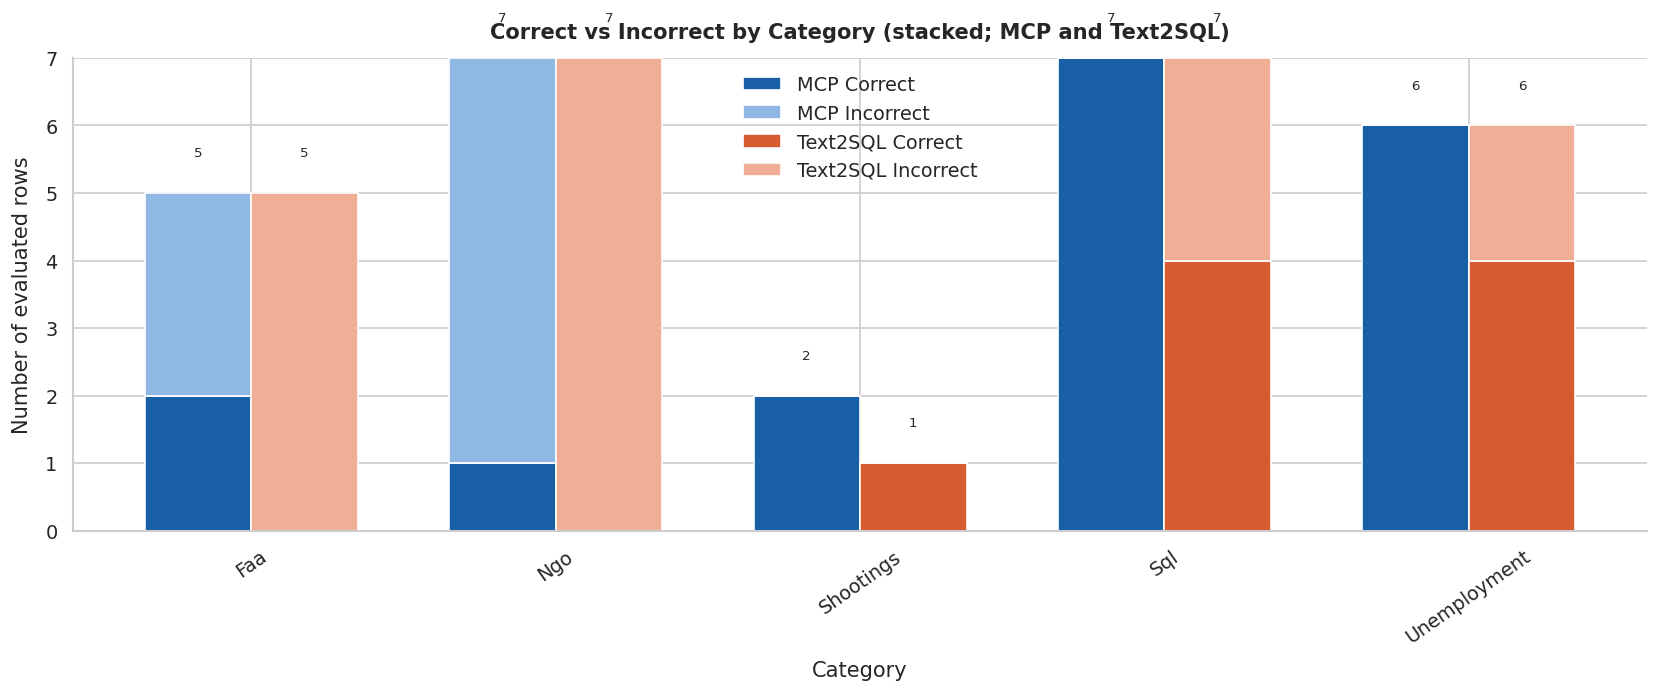

In [ ]:
scored_df = eval_results_df[eval_results_df["verdict"].isin(["correct", "incorrect"])].copy()
# Aggregate correct/incorrect counts per category and mode
agg = (
    scored_df.groupby(["category", "mode"])['is_correct']
    .agg(correct=lambda s: int(pd.Series(s).fillna(False).sum()), total='size')
    .reset_index()
)
agg['incorrect'] = agg['total'] - agg['correct']

# Ensure consistent category and mode ordering
categories = sorted(agg['category'].unique().tolist())
modes = ['mcp', 'text2sql']

# Build arrays for plotting
correct_map = {mode: [] for mode in modes}
incorrect_map = {mode: [] for mode in modes}
for cat in categories:
    for mode in modes:
        row = agg[(agg['category'] == cat) & (agg['mode'] == mode)]
        if len(row) == 0:
            correct = 0; incorrect = 0
        else:
            correct = int(row['correct'].values[0])
            incorrect = int(row['incorrect'].values[0])
        correct_map[mode].append(correct)
        incorrect_map[mode].append(incorrect)

import numpy as np
x = np.arange(len(categories))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))

mcp_pos = x - width/2
t2s_pos = x + width/2

mcp_correct = np.array(correct_map['mcp'])
mcp_incorrect = np.array(incorrect_map['mcp'])
t2s_correct = np.array(correct_map['text2sql'])
t2s_incorrect = np.array(incorrect_map['text2sql'])

p1 = ax.bar(mcp_pos, mcp_correct, width, color='#185FA5', label='MCP Correct')
p2 = ax.bar(mcp_pos, mcp_incorrect, width, bottom=mcp_correct, color='#8FB9E3', label='MCP Incorrect')
p3 = ax.bar(t2s_pos, t2s_correct, width, color='#D85A30', label='Text2SQL Correct')
p4 = ax.bar(t2s_pos, t2s_incorrect, width, bottom=t2s_correct, color='#F1AE97', label='Text2SQL Incorrect')

ax.set_xticks(x)
ax.set_xticklabels([c.title() for c in categories], rotation=35)
ax.set_xlabel('Category', labelpad=8)
ax.set_ylabel('Number of evaluated rows', labelpad=8)
ax.set_title('Correct vs Incorrect by Category (stacked; MCP and Text2SQL)', fontweight='bold', pad=12)

# Annotate totals above each bar
# for pos, total in zip(list(mcp_pos) + list(t2s_pos), list((mcp_correct + mcp_incorrect)) + list((t2s_correct + t2s_incorrect))):
#     ax.text(pos, total + 0.5, str(int(total)), ha='center', va='bottom', fontsize=8)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()


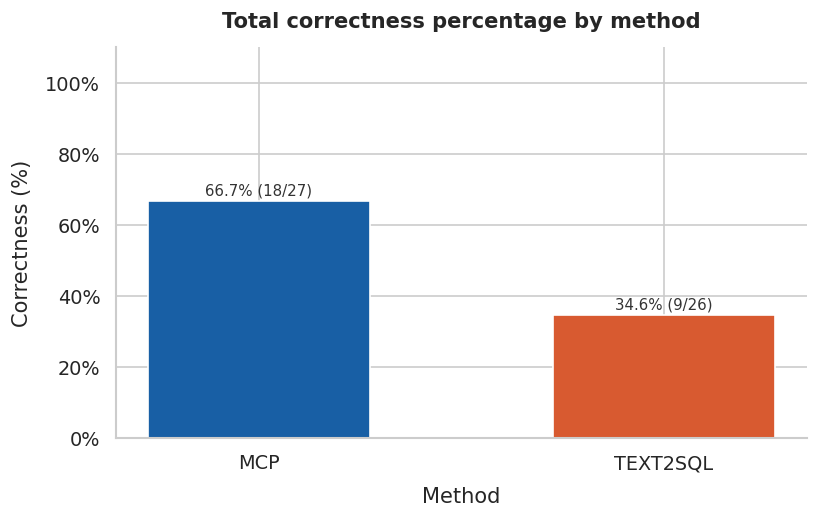

Correctness summary table


,mode,total_rows,scorable_rows,correct_rows,incorrect_rows,unscorable_rows,correct_pct
0,mcp,27,27,18,9,0,66.666667
1,text2sql,27,26,9,17,1,34.615385


In [8]:
mode_summary = (
    eval_results_df.groupby("mode", dropna=False)
    .agg(
        total_rows=("question_id", "size"),
        scorable_rows=("verdict", lambda s: s.isin(["correct", "incorrect"]).sum()),
        correct_rows=("is_correct", lambda s: pd.Series(s).fillna(False).sum()),
        unscorable_rows=("verdict", lambda s: (s == "unscorable").sum()),
    )
    .reset_index()
)
mode_summary["incorrect_rows"] = mode_summary["scorable_rows"] - mode_summary["correct_rows"]
mode_summary["correct_pct"] = np.where(
    mode_summary["scorable_rows"] > 0,
    (mode_summary["correct_rows"] / mode_summary["scorable_rows"]) * 100,
    np.nan,
)

mode_order = ["mcp", "text2sql"]
mode_summary["mode"] = pd.Categorical(mode_summary["mode"], categories=mode_order, ordered=True)
mode_summary = mode_summary.sort_values("mode")

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [PALETTE.get(mode, "#999999") for mode in mode_summary["mode"]]
bars = ax.bar(mode_summary["mode"].str.upper(), mode_summary["correct_pct"], color=colors, width=0.55)

for bar, pct, correct_rows, scorable_rows in zip(
    bars,
    mode_summary["correct_pct"],
    mode_summary["correct_rows"],
    mode_summary["scorable_rows"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{pct:.1f}% ({int(correct_rows)}/{int(scorable_rows)})",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#333",
    )

ax.set_ylim(0, 110)
ax.set_ylabel("Correctness (%)", labelpad=8)
ax.set_xlabel("Method", labelpad=8)
ax.set_title("Total correctness percentage by method", fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
plt.tight_layout()
plt.show()

print("Correctness summary table")
display(mode_summary[["mode", "total_rows", "scorable_rows", "correct_rows", "incorrect_rows", "unscorable_rows", "correct_pct"]])

In [9]:
output_path = "profiling_eval_gpt5mini_correctness.csv"
eval_results_df.to_csv(output_path, index=False)

unscorable_rows = eval_results_df[~eval_results_df["verdict"].isin(["correct", "incorrect"])][
    ["question_id", "mode", "category", "truth_status", "evaluation_error"]
]

print(f"Saved row-level evaluation to: {output_path}")
print(f"Unscorable rows: {len(unscorable_rows)}")
display(unscorable_rows)

Saved row-level evaluation to: profiling_eval_gpt5mini_correctness.csv
Unscorable rows: 1


,question_id,mode,category,truth_status,evaluation_error
17,q009,text2sql,shootings,ok,
